Create lists or flags for interesting subsets based on the change during one orbital period

# Imports and reads

In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
from utils.data_loader import load_parquet

# Load only specific columns that you need for analysis
# This will significantly reduce memory usage
columns_needed = ['time', 'orbital_decay']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())

✅ Successfully loaded data with shape: (3157920, 2)
                 time  orbital_decay
0 2023-01-01 00:00:00        16.6730
1 2023-01-01 00:00:20        16.6730
2 2023-01-01 00:00:40        16.6735
3 2023-01-01 00:01:00        16.6740
4 2023-01-01 00:01:20        16.6740


# Data Plot

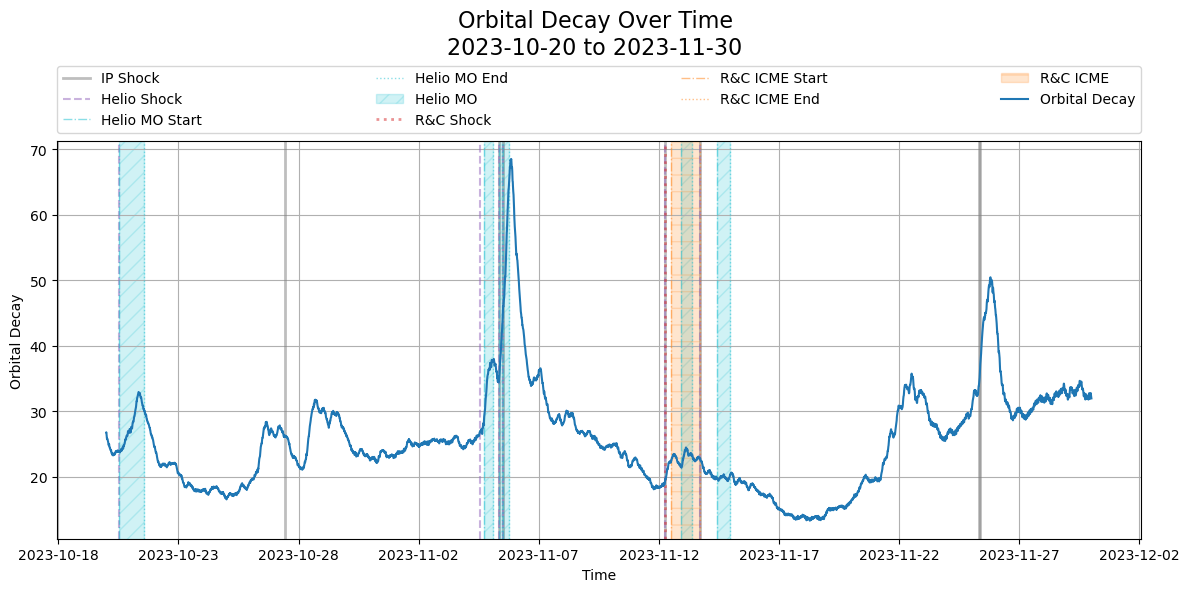

In [2]:
from utils.plot_loader import plot_orbital_decay
plot_orbital_decay(GFOC_data, start_date='2023-10-20', end_date='2023-11-30', tick_interval='daily', tick_step=5, FLAGS=True)

# Orbital Period

In [3]:
df = GFOC_data.copy()
time = df['time'].values

# make 'time' the index
df.set_index('time', inplace=True)
df.index = pd.to_datetime(df.index)

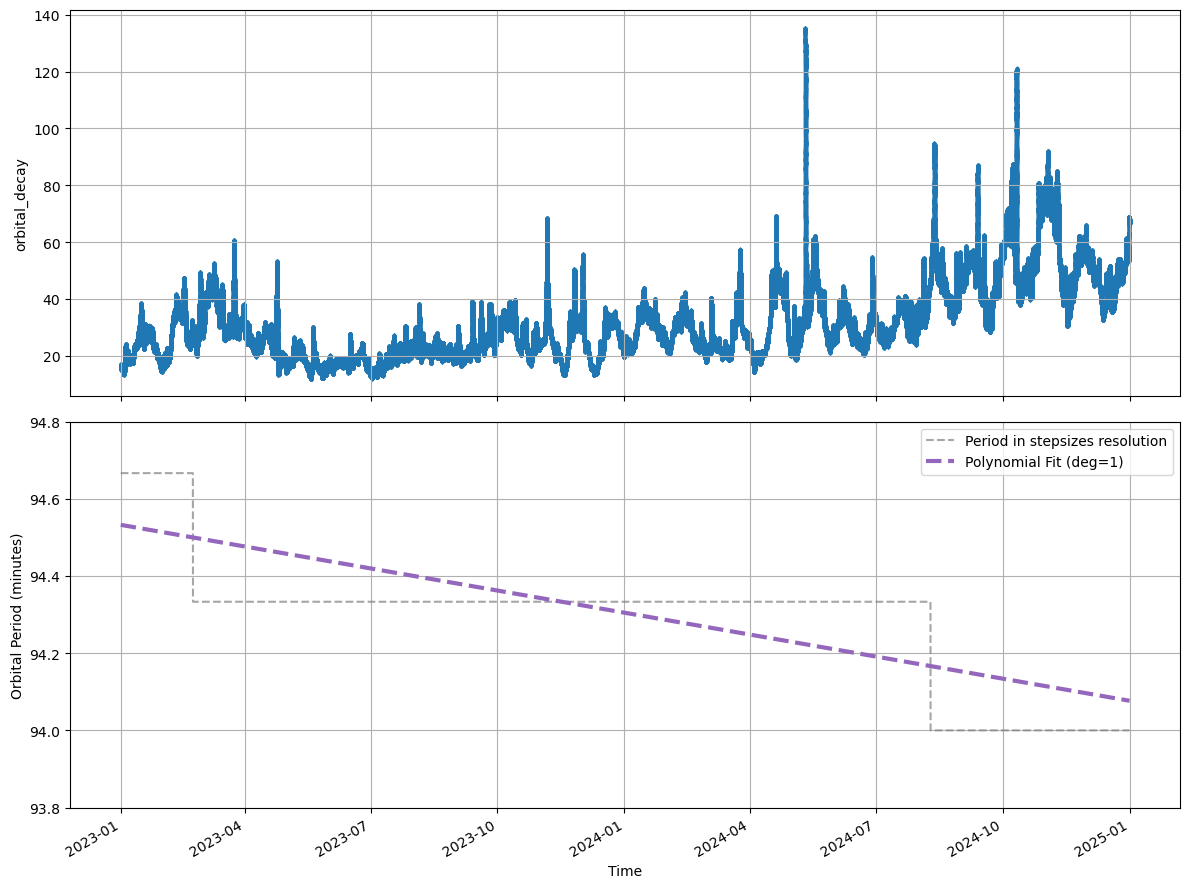

In [4]:
from numpy.polynomial import Polynomial
# period function
p_list = [ 1.06605722e+02, -7.21846851e-09]
p = Polynomial(p_list)

# plot all features from columns_needed
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

axes[0].scatter(df.index, df['orbital_decay'], s=2, c='C0', alpha=0.6)
axes[0].set_ylabel('orbital_decay')
axes[0].grid(True)

dt_seconds = (df.index[1] - df.index[0]).total_seconds()
orbital_period = p(df.index.astype(np.int64) / 1e9)
vals = orbital_period * 60 / dt_seconds
period_stepsizes = np.round(vals).astype(int)
descrete_period = period_stepsizes * dt_seconds / 60
axes[1].plot(df.index, descrete_period, c='grey', linestyle='--', label='Period in stepsizes resolution', alpha=0.7)
axes[1].plot(df.index, orbital_period, c='C4', linestyle='--', lw = 3, label='Polynomial Fit (deg=1)', alpha=1)
axes[1].set_ylabel('Orbital Period (minutes)')
axes[1].set_xlabel('Time')
axes[1].set_ylim(93.8, 94.8)
axes[1].legend()
axes[1].grid(True)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Create Shift

In [5]:
y_orig = df['orbital_decay'].to_numpy()
steps = period_stepsizes  # shape (m,)
m = len(y_orig)

# indices to sample
idx = np.arange(m) + steps

# mask out-of-range shifts
valid = idx < m

y_shift = np.full(m, np.nan)     # or 0 or whatever default you prefer
y_shift[valid] = y_orig[idx[valid]]

# final output
y = y_shift - y_orig

na_mask = np.isnan(y)
y = y[~na_mask]

# create dataframe for easier handling
y = pd.DataFrame({'orbital_decay_change': y}, index=df.index[~na_mask])

In [6]:
# print statistics about F
print("Statistics of orbital_decay change over 1 orbit:")
print(y.describe())
diff_std = y.std().iloc[0]
print(f"Number of points where |change| > 1*std ({1*diff_std:.4f}): {(y.abs() > 1*diff_std).sum()} out of {len(y)}")
print(f"Number of points where |change| > 2*std ({2*diff_std:.4f}): {(y.abs() > 2*diff_std).sum()} out of {len(y)}")
print(f"Number of points where |change| > 3*std ({3*diff_std:.4f}): {(y.abs() > 3*diff_std).sum()} out of {len(y)}")

Statistics of orbital_decay change over 1 orbit:
       orbital_decay_change
count          3.157638e+06
mean           4.569472e-03
std            1.082104e+00
min           -1.298600e+01
25%           -4.420000e-01
50%           -3.700000e-02
75%            3.960000e-01
max            2.189900e+01
Number of points where |change| > 1*std (1.0821): orbital_decay_change    510241
dtype: int64 out of 3157638
Number of points where |change| > 2*std (2.1642): orbital_decay_change    123373
dtype: int64 out of 3157638
Number of points where |change| > 3*std (3.2463): orbital_decay_change    44861
dtype: int64 out of 3157638


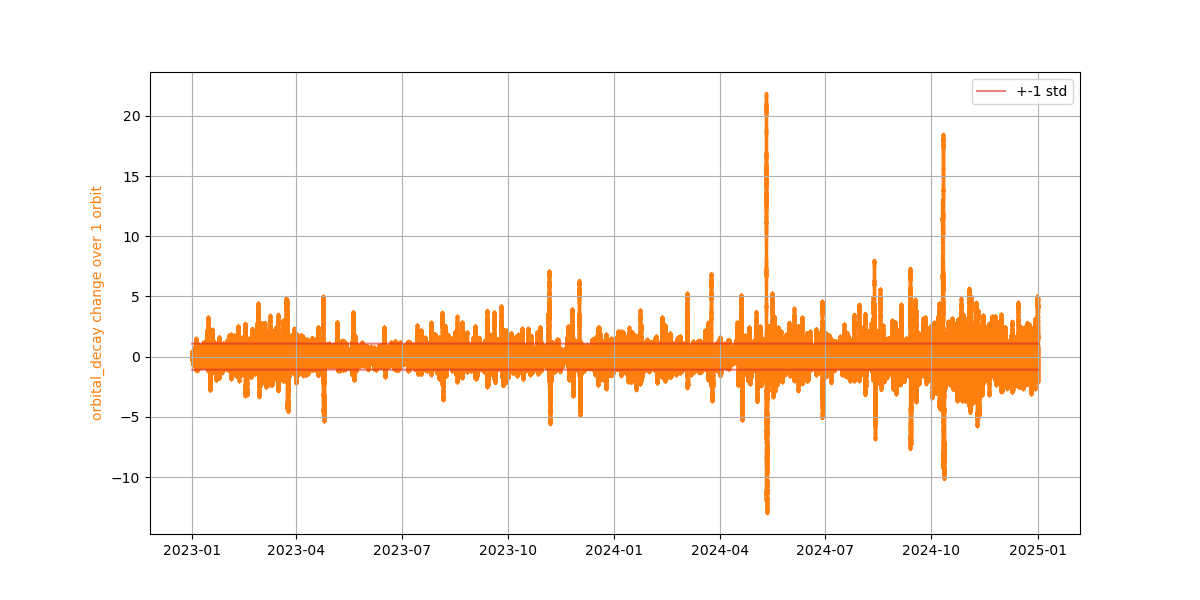

In [7]:
%matplotlib widget
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(y.index, y, s=2, c='C1', alpha=0.6)
ax.plot(y.index, [diff_std]*len(y), c='C3', alpha=0.6, label='+-1 std')
ax.plot(y.index, [-diff_std]*len(y), c='C3', alpha=0.6)
ax.grid(True)
ax.legend(loc='upper right')
ax.set_ylabel('orbital_decay change over 1 orbit', color='C1')
plt.show()

# Flag datapoints based on std

In [8]:
y['orbital_decay'] = y_orig[~na_mask]
y['period_step'] = steps[~na_mask]
y['std'] = y['orbital_decay_change'].abs()/diff_std

# round to nearest int with 3 as upper limit
y['std_round'] = y['std'].where(y['std'] > 1, 0)
y['std_round'] = y['std_round'].where(y['std'] < 1, 1)
y['std_round'] = y['std_round'].where(y['std'] < 2, 2)
y['std_round'] = y['std_round'].where(y['std'] < 3, 3)
# convert to int
y['std_round'] = y['std_round'].astype(int)

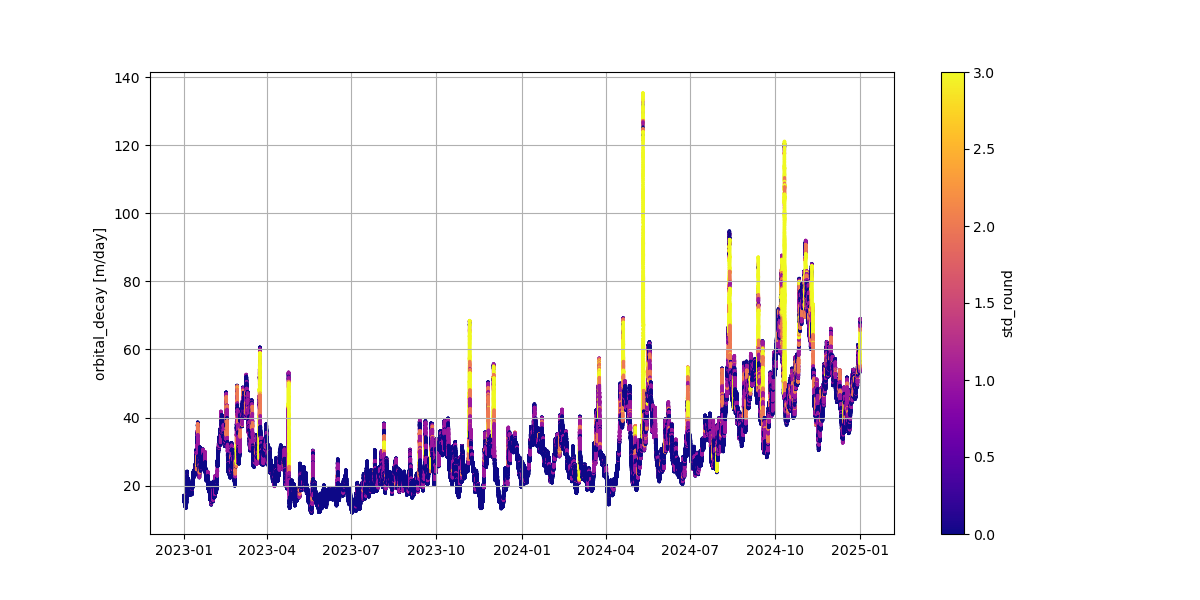

In [9]:

%matplotlib widget
fig, ax = plt.subplots(figsize=(12, 6))
# values must be numeric for colormap
sc = ax.scatter(
    y.iloc[::8].index,
    y.iloc[::8]['orbital_decay'],
    s=2,
    c=y.iloc[::8]['std_round'],         # integers 0–3
    cmap='plasma',           # choose any sequential colormap
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('std_round')
# colors = {0: 'C0', 1: 'C1', 2: 'C2', 3: 'C3'}
# c = y['std_round'].map(colors)
# ax.scatter(
#     y.index,
#     y['orbital_decay'],
#     s=2,
#     c=c,
# )

ax.grid(True)
ax.set_ylabel('orbital_decay [m/day]')
plt.show()

# Create Flag

In [10]:
y['std_flag'] = y['std_round']

mask = y['std_round'] > 0
idxs = np.flatnonzero(mask)   # array of integers
for i in idxs:
    steps = int(y.iloc[i]['period_step'])
    std = y.iloc[i]['std_round']
    # slice by integer positions
    j = i + 5*steps
    # select the window
    window = y.iloc[i:j]
    # assign max(std, current std_flag) safely
    y.iloc[i:j, y.columns.get_loc('std_flag')] = np.maximum(window['std_flag'], std)

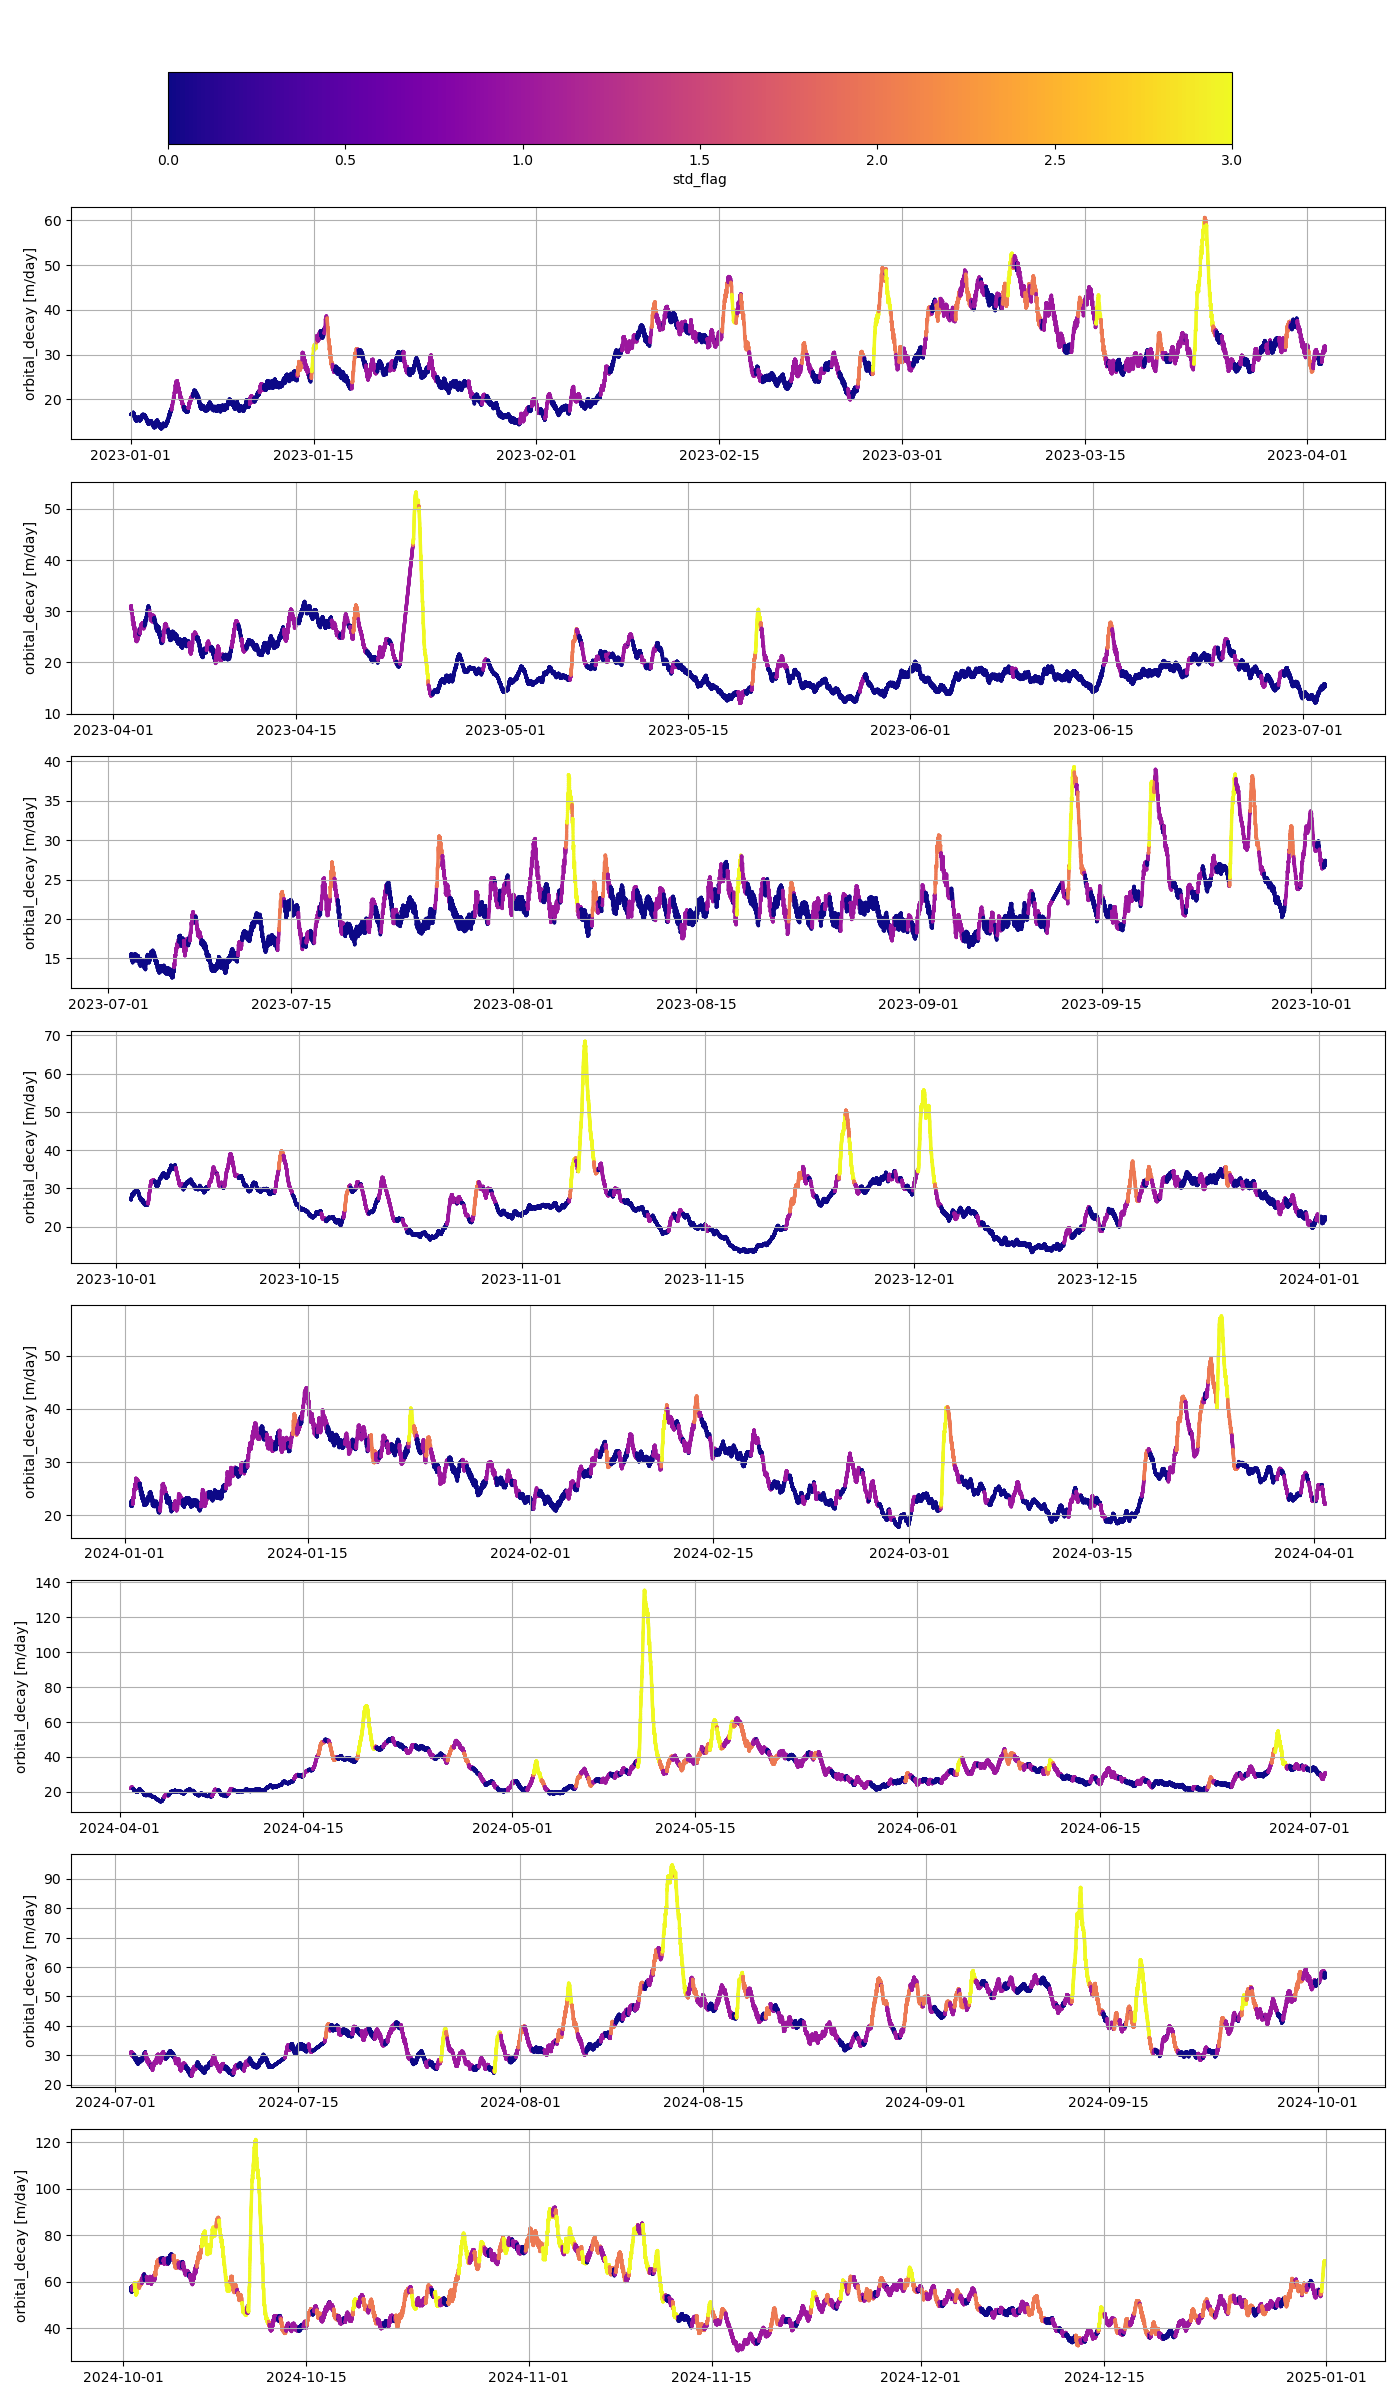

In [11]:
N = 8  # number of subplots

# Downsampled view
ysub = y.iloc[::8]

# split indices into N nearly equal chunks
splits = np.array_split(ysub.index, N)
plt.close('all')
fig, axes = plt.subplots(N, 1, figsize=(14, 3*N), sharey=False)

for ax, idx_chunk in zip(axes, splits):

    # slice the dataframe for this subplot
    chunk = ysub.loc[idx_chunk]

    # scatter plot
    sc = ax.scatter(
        chunk.index,
        chunk['orbital_decay'],
        s=2,
        c=chunk['std_flag'],
        cmap='plasma'
    )
    ax.grid(True)
    ax.set_ylabel("orbital_decay [m/day]")
    # ax.set_ylim(np.min(chunk['orbital_decay']), np.max(chunk['orbital_decay']))

# Add a single colorbar for all subplots
plt.tight_layout(rect=[0, 0, 1, 0.92])   # leave top 8% free for the colorbar
cbar_ax = fig.add_axes([0.12, 0.94, 0.76, 0.03])  # adjust numbers if needed
fig.colorbar(sc, cax=cbar_ax, orientation='horizontal', label='std_flag')

plt.show()

# Create Mean from std values

In [12]:
std_arr = y['std'].to_numpy()
steps_arr = y['period_step'].astype(int).to_numpy()

N = len(y)
mean_vals = np.empty(N)

for i in range(N):
    s = steps_arr[i]
    multiple = 3
    # compute boundaries, clipped to valid range
    left = max(0, i - multiple * s)
    right = min(N, i + multiple * s + 1)

    mean_vals[i] = std_arr[left:right].mean()

y['mean_std'] = mean_vals

In [13]:
y['mean_std_round'] = y['mean_std'].where(y['mean_std'] > 1, 0)
y['mean_std_round'] = y['mean_std_round'].where(y['mean_std'] < 1, 1)
y['mean_std_round'] = y['mean_std_round'].where(y['mean_std'] < 2, 2)
y['mean_std_round'] = y['mean_std_round'].where(y['mean_std'] < 3, 3)
# convert to int
y['mean_std_round'] = y['mean_std_round'].astype(int)

In [14]:
y['mean_std_flag'] = y['mean_std_round']

mask = y['mean_std_round'] > 0
idxs = np.flatnonzero(mask)   # array of integers
for i in idxs:
    steps = int(y.iloc[i]['period_step'])
    std = y.iloc[i]['mean_std_round']
    # slice by integer positions
    j = i + 5*steps
    # select the window
    window = y.iloc[i:j]
    # assign max(std, current std_flag) safely
    y.iloc[i:j, y.columns.get_loc('mean_std_flag')] = np.maximum(window['mean_std_flag'], std)

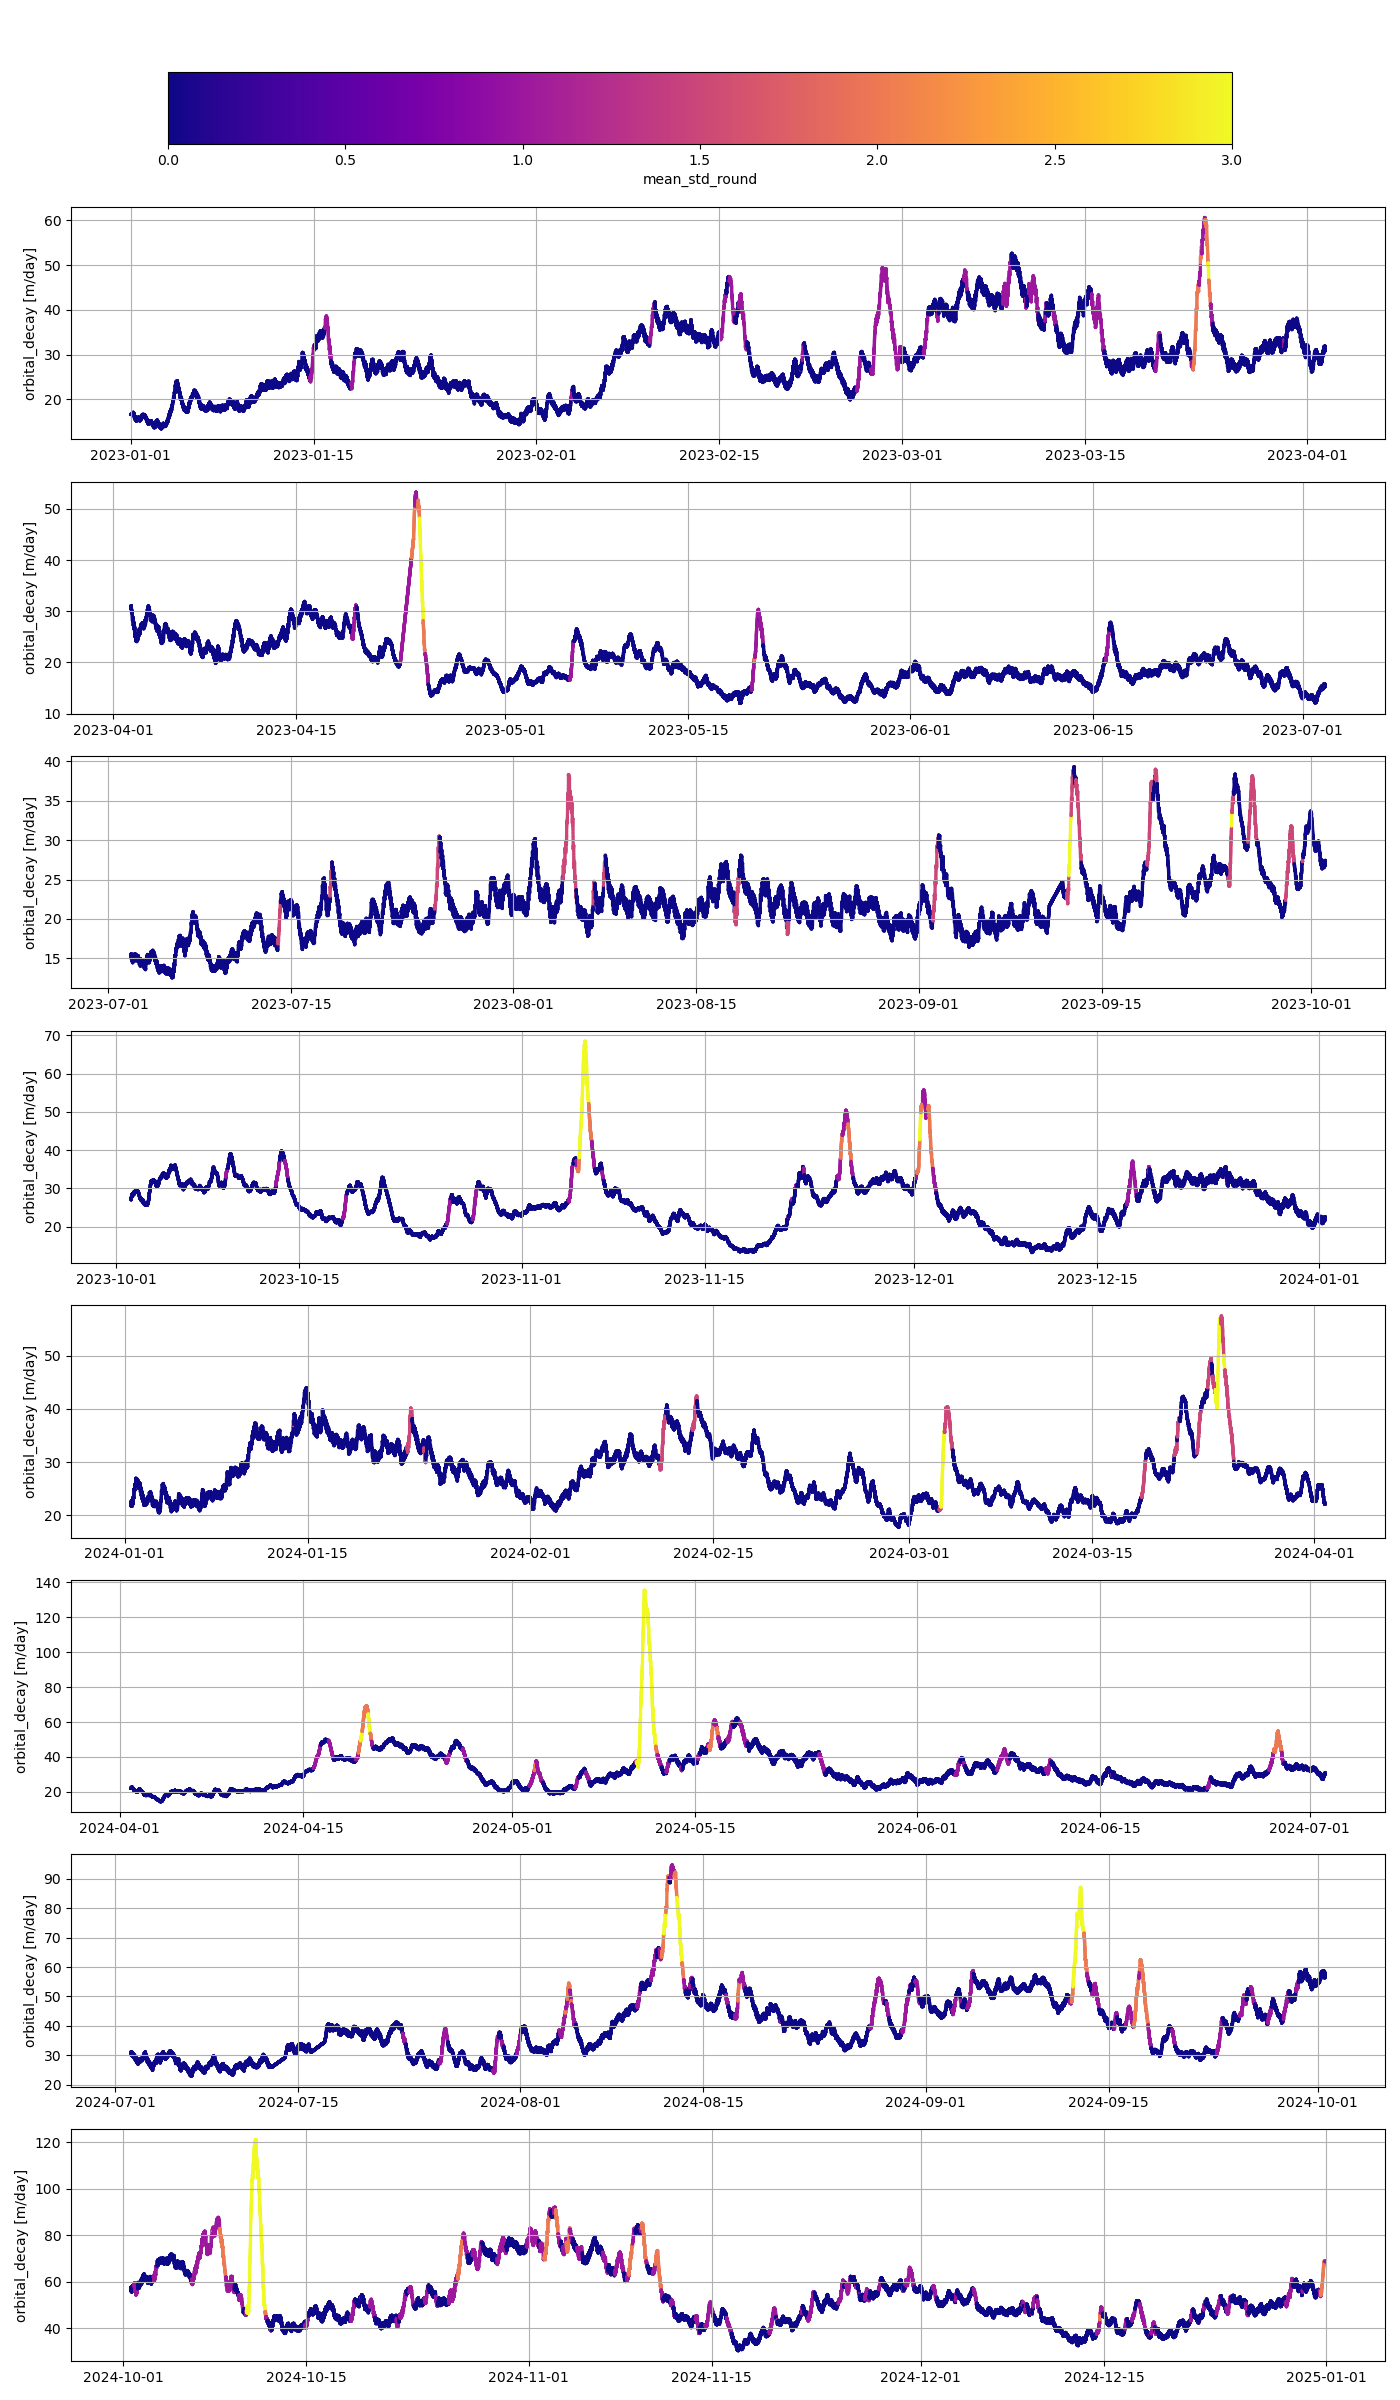

In [15]:
N = 8  # number of subplots

# Downsampled view
ysub = y.iloc[::8]

# split indices into N nearly equal chunks
splits = np.array_split(ysub.index, N)
plt.close('all')
fig, axes = plt.subplots(N, 1, figsize=(14, 3*N), sharey=False)

for ax, idx_chunk in zip(axes, splits):

    # slice the dataframe for this subplot
    chunk = ysub.loc[idx_chunk]

    # scatter plot
    sc = ax.scatter(
        chunk.index,
        chunk['orbital_decay'],
        s=2,
        c=chunk['mean_std_round'],
        cmap='plasma'
    )
    ax.grid(True)
    ax.set_ylabel("orbital_decay [m/day]")
    # ax.set_ylim(np.min(chunk['orbital_decay']), np.max(chunk['orbital_decay']))

# Add a single colorbar for all subplots
plt.tight_layout(rect=[0, 0, 1, 0.92])   # leave top 8% free for the colorbar
cbar_ax = fig.add_axes([0.12, 0.94, 0.76, 0.03])  # adjust numbers if needed
fig.colorbar(sc, cax=cbar_ax, orientation='horizontal', label='mean_std_round')

plt.show()

In [16]:
y.head()

,orbital_decay_change,orbital_decay,period_step,std,std_round,std_flag,mean_std,mean_std_round,mean_std_flag
time,,,,,,,,,
2023-01-01 00:00:00,0.0260,16.6730,284,0.024027,0,0,0.117848,0,0
2023-01-01 00:00:20,0.0260,16.6730,284,0.024027,0,0,0.118121,0,0
2023-01-01 00:00:40,0.0255,16.6735,284,0.023565,0,0,0.118396,0,0
2023-01-01 00:01:00,0.0250,16.6740,284,0.023103,0,0,0.118665,0,0
2023-01-01 00:01:20,0.0250,16.6740,284,0.023103,0,0,0.118924,0,0


# Find subgroups where std_flag != 0

In [17]:
def find_intervals(dataframe, col='std_flag', min_duration=pd.Timedelta(days=1), threshold=[0]):
    mask = ~dataframe[col].isin(threshold)
    new_group = (mask != mask.shift()).cumsum()
    active = mask.groupby(new_group)
    active_groups = [g.index for _, g in dataframe[mask].groupby(new_group[mask])]
    long_segments = [
        seg
        for seg in active_groups
        if seg[-1] - seg[0] >= min_duration
    ]
    intervals = [(seg[0], seg[-1]) for seg in long_segments]
    return intervals

intervals = find_intervals(y, col='mean_std_flag', min_duration=pd.Timedelta(days=1), threshold=[0])
# save intervals to csv
intervals_df = pd.DataFrame(intervals, columns=['start', 'end'])
intervals_df.to_csv('./Analysis/modeling/subsets_meanstd.csv', index=False)

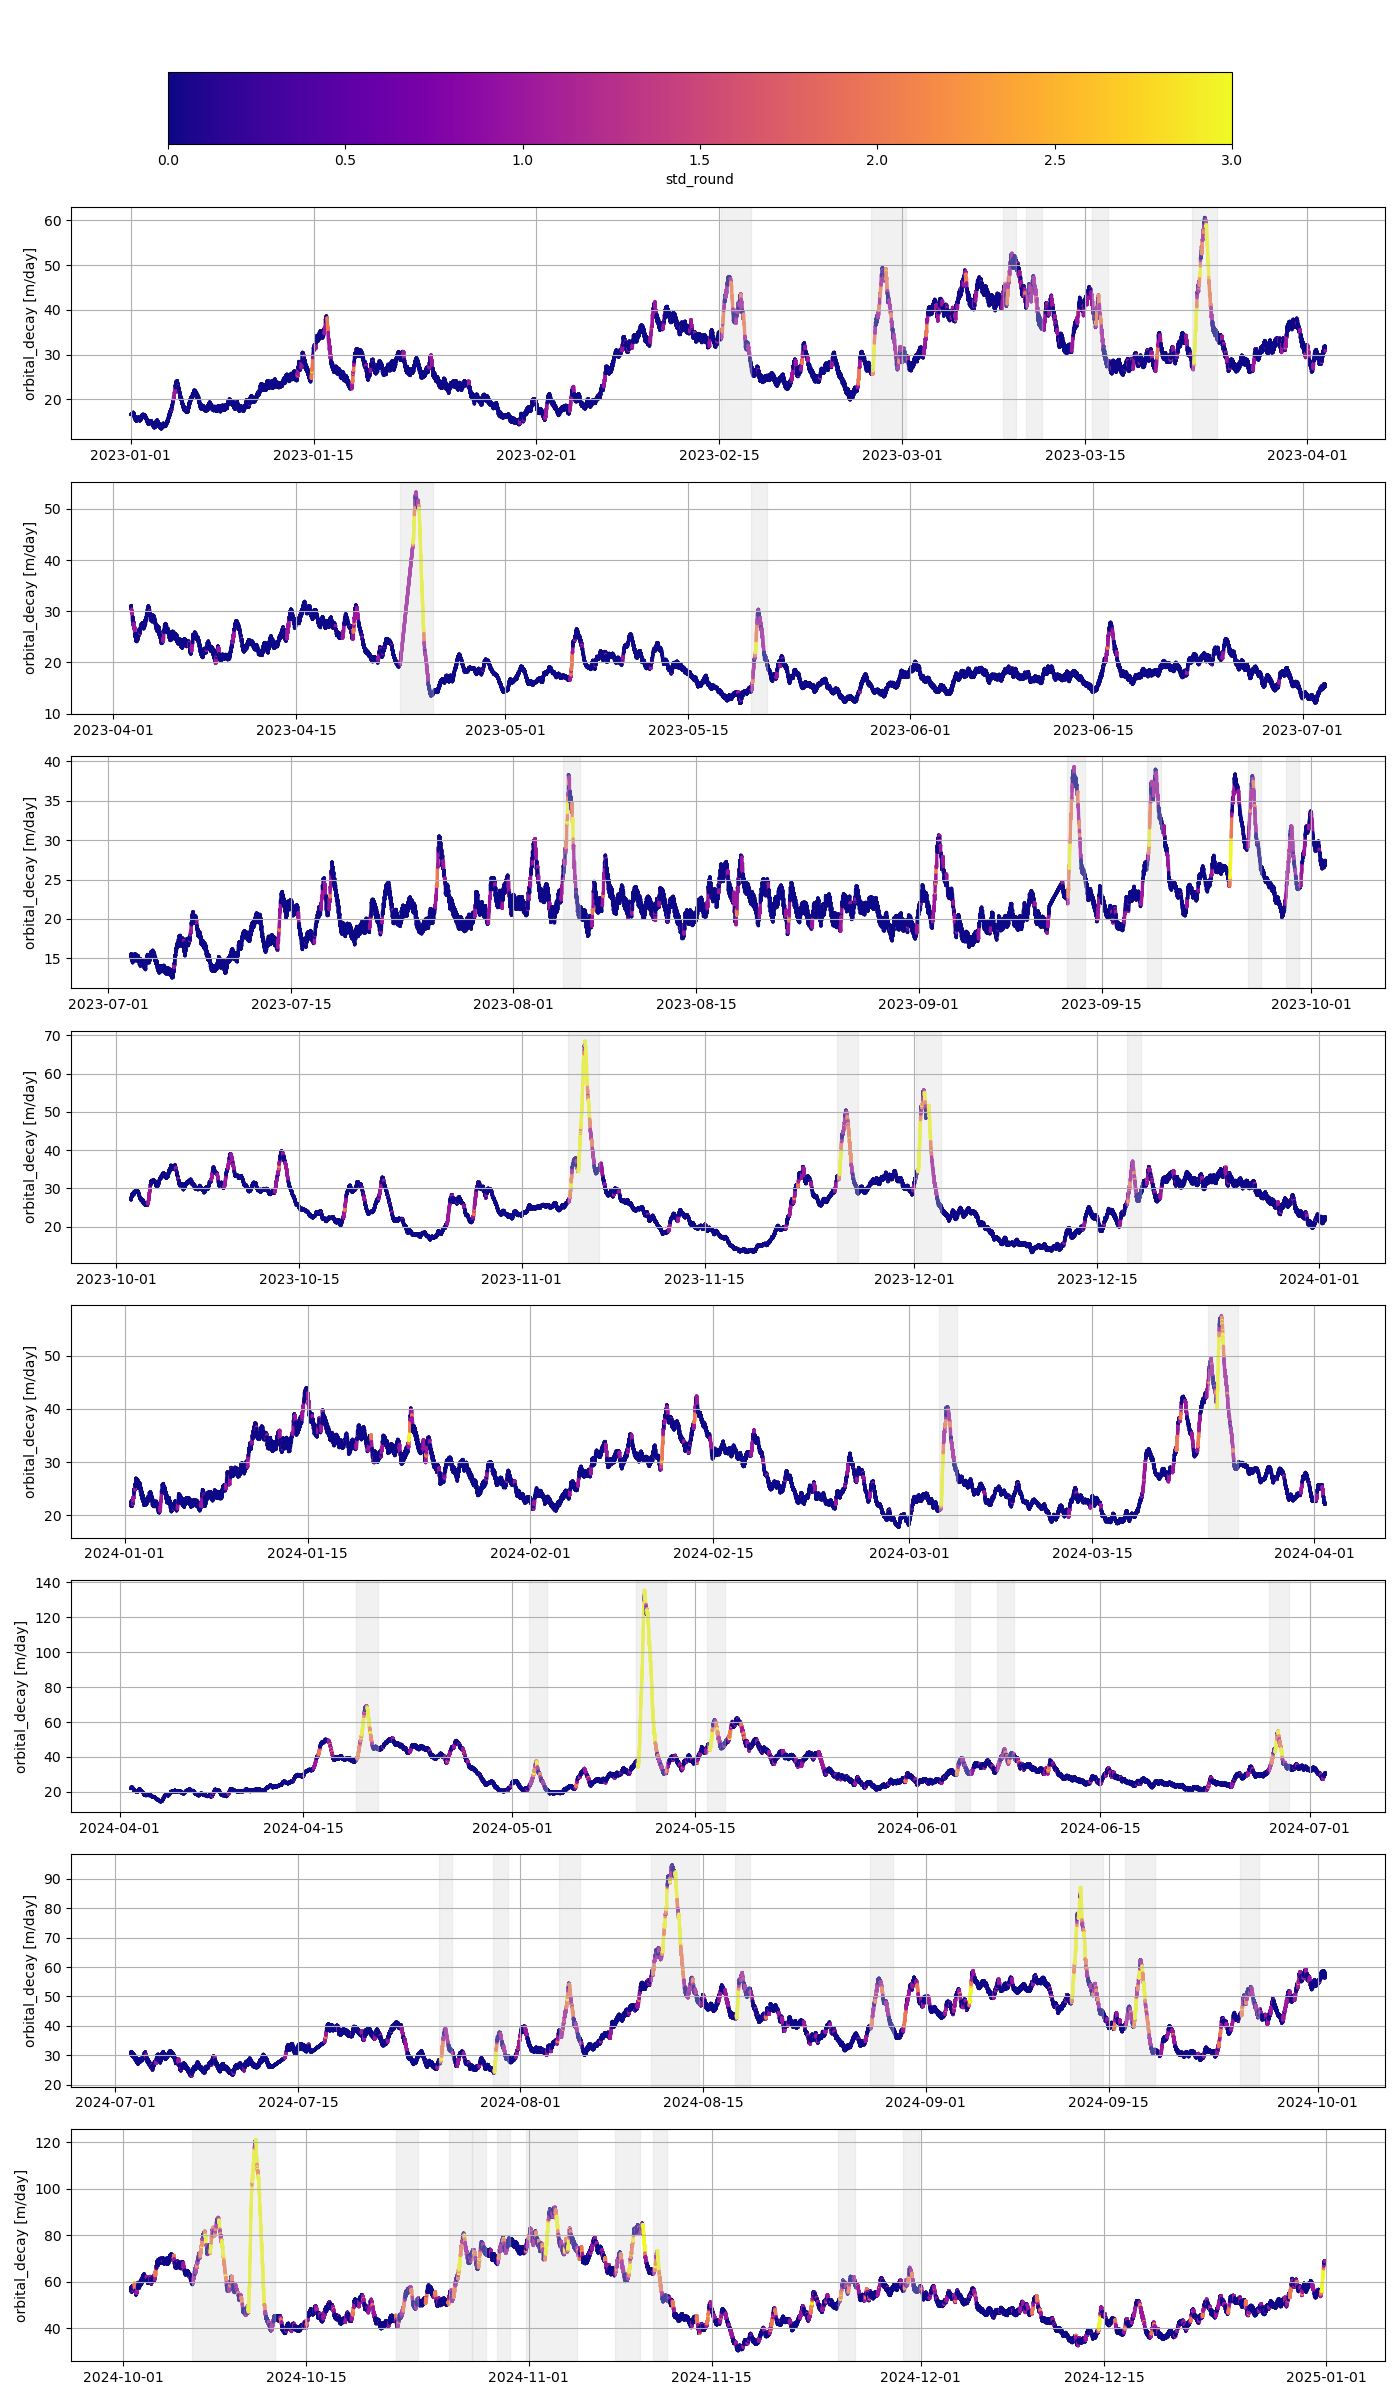

In [18]:
N = 8  # number of subplots

# Downsampled view
ysub = y.iloc[::8]

# split indices into N nearly equal chunks
splits = np.array_split(ysub.index, N)
plt.close('all')
fig, axes = plt.subplots(N, 1, figsize=(14, 3*N), sharey=False)

for ax, idx_chunk in zip(axes, splits):

    # slice the dataframe for this subplot
    chunk = ysub.loc[idx_chunk]

    # scatter plot
    sc = ax.scatter(
        chunk.index,
        chunk['orbital_decay'],
        s=2,
        c=chunk['std_round'],
        cmap='plasma'
    )

    # highlight intervals for this subplot
    for start, end in intervals:
        # only draw if this interval overlaps the current x-range
        if start <= chunk.index[-1] and end >= chunk.index[0]:
            ax.axvspan(start, end, color='lightgrey', alpha=0.3)

    ax.grid(True)
    ax.set_ylabel("orbital_decay [m/day]")
    # ax.set_ylim(np.min(chunk['orbital_decay']), np.max(chunk['orbital_decay']))

# Add a single colorbar for all subplots
plt.tight_layout(rect=[0, 0, 1, 0.92])   # leave top 8% free for the colorbar
cbar_ax = fig.add_axes([0.12, 0.94, 0.76, 0.03])  # adjust numbers if needed
fig.colorbar(sc, cax=cbar_ax, orientation='horizontal', label='std_round')

plt.show()